In [258]:
class BaseBot:
    def __init__(
        self,
        start_bank,
        bank,
        fee,
        choice,
        profit_rate,
        bias_threshold,
        history_threshold,
        switch_threshold,
    ):
        self.start_bank = start_bank
        self.bank = bank
        self.fee = fee
        self.choice = choice
        self.consecutive_losses = 0
        self.bank_history = []
        self.round = 0
        self.result_history = []
        self.profit_target = self.bank * profit_rate
        self.peak = 0
        self.bias_threshold = bias_threshold
        self.history_threshold = history_threshold
        self.switch_threshold = switch_threshold
        self.CHIPS = [1, 5, 10, 25, 50, 100]

    def calculate_fee(self, stake):
        return self.fee + stake + stake * 5 / 100

    def update_history(self):
        self.bank_history.append(self.bank)

    def handle_result(self, win, result):
        self.result_history.append(result)

        # Update consecutive losses counter
        if win:
            self.consecutive_losses = 0
        else:
            self.consecutive_losses += 1

        # Only consider switching if we have enough history
        if (
            len(self.result_history) >= self.history_threshold
            and self.consecutive_losses >= self.switch_threshold
        ):
            # Calculate recent results
            recent_results = self.result_history
            heads_count = sum(1 for r in recent_results if r)
            tails_count = len(recent_results) - heads_count

            # Calculate outcome frequencies
            total_flips = len(recent_results)
            heads_frequency = heads_count / total_flips
            tails_frequency = tails_count / total_flips

            # If there's a bias toward one outcome, choose the opposite
            # (i.e., if we see more heads, bet on tails and vice versa)
            if (
                abs(heads_frequency - tails_frequency) > self.bias_threshold
            ):  # 15% threshold
                # Switch to the side with lower frequency (bet against the trend)
                self.choice = (
                    heads_frequency < tails_frequency
                )  # True if should choose tails

        elif self.consecutive_losses > self.switch_threshold:
            self.choice = not self.choice  # Switch back to the original choice

In [266]:
import math


class KellySwitchBot(BaseBot):
    def __init__(
        self,
        start_bank=1000,
        bank=1000,
        fee=0.32,
        choice=True,
        profit_rate=1.7,
        bias_threshold=0.15,
        history_threshold=20,
        switch_threshold=3,
        trailing_stop_rate=0.9,
        f=0.17,
        decay_rate=0.002,
    ):
        super().__init__(
            start_bank,
            bank,
            fee,
            choice,
            profit_rate,
            bias_threshold,
            history_threshold,
            switch_threshold,
        )
        self.f = f
        self.index = 0
        self.trailing_stop_rate = trailing_stop_rate
        self.decay_rate = decay_rate

    def play_round(self, result_bool):
        self.peak = max(self.peak, self.bank)
        if self.peak >= self.profit_target:
            # If we have reached the profit target, stop playing
            return "EARLY_EXIT"
        if self.bank < self.calculate_fee(self.CHIPS[0]):
            # If we don't have enough to play, stop playing
            return "BANKRUPT"

        win = result_bool == self.choice
        min_cost = self.calculate_fee(self.CHIPS[0])
        prv_idx = self.index

        if self.bank >= min_cost:
            # target = self.f * self.bank
            decay = math.exp(-self.decay_rate * self.bank)  # λ = 0.002
            target = self.f * decay * self.bank
            stake = self.CHIPS[0]
            for c in reversed(self.CHIPS):
                if c <= target:
                    stake = c
                    break

            cost = self.calculate_fee(stake)
            if cost <= self.bank:
                self.round += 1
                self.bank -= cost
                if win:
                    self.bank += self.CHIPS[prv_idx] * 2

        self.handle_result(win, result_bool)
        self.update_history()

        return "CONTINUE"

In [270]:
class LadderSwitchBot(BaseBot):
    def __init__(
        self,
        start_bank=1000,
        bank=1000,
        fee=0.32,
        choice=True,
        profit_rate=1.7,
        bias_threshold=0.15,
        history_threshold=20,
        switch_threshold=3,
        stage_decay=0.2,
        trailing_stop_rate=0.9,
    ):
        super().__init__(
            start_bank,
            bank,
            fee,
            choice,
            profit_rate,
            bias_threshold,
            history_threshold,
            switch_threshold,
        )
        self.index = 0
        self.stage_decay = stage_decay
        self.trailing_stop_rate = trailing_stop_rate

    def play_round(self, result_bool):
        self.peak = max(self.peak, self.bank)
        if self.peak >= self.profit_target:
            # If we have reached the profit target, stop playing
            return "EARLY_EXIT"
        if self.bank < self.calculate_fee(self.CHIPS[0]):
            # If we don't have enough to play, stop playing
            return "BANKRUPT"

        win = result_bool == self.choice
        stake = self.CHIPS[self.index]
        cost = self.calculate_fee(stake)
        prv_idx = self.index

        if cost <= self.bank:
            self.round += 1
            self.bank -= cost
            if win:
                self.bank += self.CHIPS[prv_idx] * 2
                self.index = 0
            else:
                # Apply late stage decay - if bank is getting low, be more conservative
                if (
                    self.bank < self.start_bank * self.stage_decay
                ):  # When bank falls below 20% of starting value
                    # Either stay at current level or decrease it
                    if (
                        self.index > 0
                        and self.consecutive_losses > self.switch_threshold
                    ):
                        self.index -= 1  # Reduce bet size when losing and low on funds

                # Normal ladder climbing behavior
                elif self.index < len(self.CHIPS) - 1:
                    self.index += 1  # climb ladder

        self.handle_result(win, result_bool)
        self.update_history()

        return "CONTINUE"

In [271]:
from pymoo.core.problem import ElementwiseProblem
import numpy as np
import multiprocessing
from pymoo.core.problem import StarmapParallelization
from multiprocessing.pool import ThreadPool

class LadderSwitchOptimization(ElementwiseProblem):
    def __init__(
        self,
        start_bank=1000,
        fee=0.32,
        choice=True,
        max_round=100,
        elementwise_runner=None,
    ):
        # Parameter boundaries based on LadderSwitchBot logic:
        # bias_threshold: [0.0001, 0.5], history_threshold: [1, 100], switch_threshold: [0, MAX_ROUND], stage_decay: [0.05, 0.5], profit_rate: [1.5, 5.0], trailing_stop_rate: [0.5, 1.0]
        xl = np.array([0.0001, 1, 1, 0.05, 1.5, 0])
        xu = np.array([0.5, 100, max_round / 2, 0.9, 5, 1])
        super().__init__(
            n_var=6,
            n_obj=1,
            n_ieq_constr=0,
            xl=xl,
            xu=xu,
            elementwise_runner=elementwise_runner,
            elementwise_evaluation=True,
        )
        self.start_bank = start_bank
        self.bank = start_bank
        self.fee = fee
        self.choice = choice
        self.max_round = max_round
        self.runs = []
        self.runner = elementwise_runner

        for i in range(100):
            np.random.seed(i)
            self.runs += [np.random.choice([True, False], size=self.max_round)]

    def _evaluate(self, x, out, *args, **kwargs):
        # x: [bias_threshold, history_threshold, switch_threshold, stage_decay]
        bias_threshold = float(x[0])
        history_threshold = int(round(x[1]))
        switch_threshold = int(round(x[2]))
        stage_decay = float(x[3])
        profit_rate = float(x[4])
        trailing_stop_rate = float(x[5])

        def simulate_run(bot, results):
            assert len(results) == self.max_round
            for r in results:
                status = bot.play_round(r)
                if status == "EARLY_EXIT" or status == "BANKRUPT":
                    break
            return bot.round, bot.bank

        rounds = []
        banks = []
        for run in self.runs:
            # Generate random coin flips
            bot = LadderSwitchBot(
                start_bank=self.start_bank,
                bank=self.start_bank,
                fee=self.fee,
                choice=self.choice,
                profit_rate=profit_rate,
                bias_threshold=bias_threshold,
                history_threshold=history_threshold,
                switch_threshold=switch_threshold,
                stage_decay=stage_decay,
                trailing_stop_rate=trailing_stop_rate,
            )

            # Simulate the run
            rounds_run, banks_run = simulate_run(bot, run)
            assert rounds_run <= self.max_round
            rounds.append(rounds_run)
            banks.append(banks_run)

        # Objective 1: minimize rounds played
        # Objective 2: maximize profit (minimize negative profit)
        out["F"] = [-np.mean(banks)]

        # # Objective 1: minimize rounds played
        # # Objective 2: maximize profit (minimize negative profit)
        # out["F"] = [np.mean(bot.round), -np.mean(bot.bank)]


n_threads = 8
pool = ThreadPool(n_threads)
runner = StarmapParallelization(pool.starmap)


start_bank = 1000
fee = 0.6
choice = True
max_round = 1000
problem = LadderSwitchOptimization(
    start_bank, fee, choice, max_round, elementwise_runner=runner
)

In [267]:
class KellySwitchOptimization(ElementwiseProblem):
    def __init__(
        self,
        start_bank=1000,
        fee=0.32,
        choice=True,
        max_round=100,
        elementwise_runner=None,
    ):
        # Parameter boundaries based on KellySwitchBot logic:
        # bias_threshold: [0.0001, 0.5], history_threshold: [1, 100], switch_threshold: [0, MAX_ROUND], profit_rate: [1.5, 5.0], trailing_stop_rate: [0.5, 1.0], f: [0.01, 0.5], decay_rate: [0.000001, 0.1]
        xl = np.array([0.0001, 1, 1, 1.5, 0.5, 0.001, 0.000001])
        xu = np.array([0.5, 100, max_round / 2, 5, 1.0, 0.5, 0.1])
        super().__init__(
            n_var=7,
            n_obj=1,
            n_ieq_constr=0,
            xl=xl,
            xu=xu,
            elementwise_runner=elementwise_runner,
            elementwise_evaluation=True,
        )
        self.start_bank = start_bank
        self.bank = start_bank
        self.fee = fee
        self.choice = choice
        self.max_round = max_round
        self.runs = []
        self.runner = elementwise_runner

        for i in range(200):
            np.random.seed(i)
            self.runs += [np.random.choice([True, False], size=self.max_round)]

    def _evaluate(self, x, out, *args, **kwargs):
        # x: [bias_threshold, history_threshold, switch_threshold, profit_rate, trailing_stop_rate, f]
        bias_threshold = float(x[0])
        history_threshold = int(round(x[1]))
        switch_threshold = int(round(x[2]))
        profit_rate = float(x[3])
        trailing_stop_rate = float(x[4])
        f = float(x[5])
        decay_rate = float(x[6])

        def simulate_run(bot, results):
            assert len(results) == self.max_round
            for r in results:
                status = bot.play_round(r)
                if status == "EARLY_EXIT" or status == "BANKRUPT":
                    break
            return bot.round, bot.bank

        rounds = []
        banks = []
        for run in self.runs:
            bot = KellySwitchBot(
                start_bank=self.start_bank,
                bank=self.start_bank,
                fee=self.fee,
                choice=self.choice,
                profit_rate=profit_rate,
                bias_threshold=bias_threshold,
                history_threshold=history_threshold,
                switch_threshold=switch_threshold,
                trailing_stop_rate=trailing_stop_rate,
                f=f,
                decay_rate=decay_rate,
            )
            rounds_run, banks_run = simulate_run(bot, run)
            assert rounds_run <= self.max_round
            rounds.append(rounds_run)
            banks.append(banks_run)

        out["F"] = [-np.mean(banks)]


n_threads = 16
pool = ThreadPool(n_threads)
runner = StarmapParallelization(pool.starmap)


start_bank = 1000
fee = 0.6
choice = True
max_round = 1000
problem = KellySwitchOptimization(
    start_bank, fee, choice, max_round, elementwise_runner=runner
)

In [272]:
from pymoo.algorithms.soo.nonconvex.de import DE
from pymoo.operators.sampling.lhs import LHS

algorithm = DE(
    # population size should be at least 10 times problem size
    pop_size=100,
    sampling=LHS(),
    variant="DE/rand/1/bin",
    CR=0.9,
    dither="vector",
    jitter=True,
    # turn on this to analyze speed of convergence
    save_history=True,
)

In [273]:
from pymoo.optimize import minimize
from pymoo.termination import get_termination

termination = get_termination("n_gen", 200)

res = minimize(problem, algorithm, termination, seed=2, save_history=True, verbose=True)
print("Threads:", res.exec_time)
# Properly close the multiprocessing pool to avoid zombie processes and pickling errors
X = res.X
F = res.F

n_gen  |  n_eval  |     f_avg     |     f_min    
     1 |      100 | -2.046227E+02 | -2.824610E+02
     2 |      200 | -2.179417E+02 | -2.862400E+02
     3 |      300 | -2.321199E+02 | -2.863975E+02
     4 |      400 | -2.454626E+02 | -2.864305E+02
     5 |      500 | -2.590018E+02 | -2.864450E+02
     6 |      600 | -2.728654E+02 | -2.864450E+02
     7 |      700 | -2.795064E+02 | -2.903440E+02
     8 |      800 | -2.823170E+02 | -2.903440E+02
     9 |      900 | -2.850155E+02 | -3.038035E+02
    10 |     1000 | -2.860647E+02 | -3.038035E+02
    11 |     1100 | -2.865968E+02 | -3.038035E+02
    12 |     1200 | -2.868269E+02 | -3.038035E+02
    13 |     1300 | -2.868532E+02 | -3.038035E+02
    14 |     1400 | -2.869722E+02 | -3.038035E+02
    15 |     1500 | -2.869782E+02 | -3.038035E+02
    16 |     1600 | -2.870092E+02 | -3.038035E+02
    17 |     1700 | -2.871873E+02 | -3.038035E+02
    18 |     1800 | -2.872227E+02 | -3.038035E+02
    19 |     1900 | -2.873944E+02 | -3.038035E+02


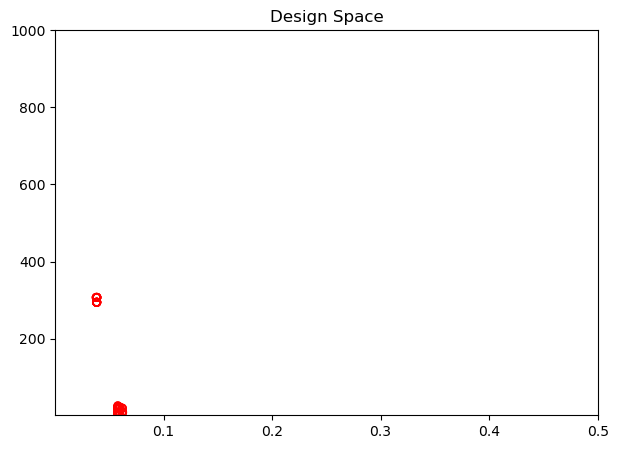

In [199]:
import matplotlib.pyplot as plt

xl, xu = problem.bounds()
plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], s=30, facecolors="none", edgecolors="r")
plt.xlim(xl[0], xu[0])
plt.ylim(xl[1], xu[1])
plt.title("Design Space")
plt.show()

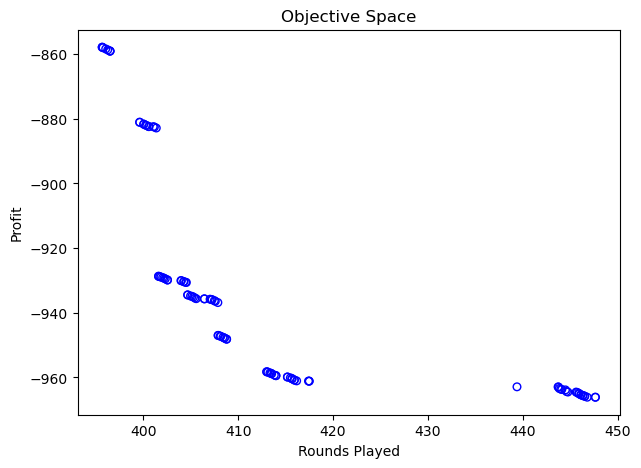

In [200]:
plt.figure(figsize=(7, 5))
plt.scatter(F[:, 0], F[:, 1], s=30, facecolors="none", edgecolors="blue")
plt.xlabel("Rounds Played")
plt.ylabel("Profit")
plt.title("Objective Space")
plt.show()

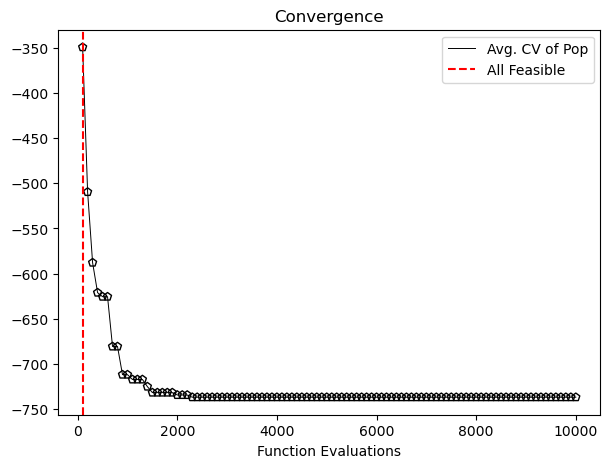

In [264]:
import matplotlib.pyplot as plt

# X, F = res.opt.get("X", "F")
hist = res.history
n_evals = []  # corresponding number of function evaluations\
hist_F = []  # the objective space values in each generation
hist_cv = []  # constraint violation in each generation
hist_cv_avg = []  # average constraint violation in the whole population

for algo in hist:
    # store the number of function evaluations
    n_evals.append(algo.evaluator.n_eval)

    # retrieve the optimum from the algorithm
    opt = algo.opt
    hist_F.append(opt.get("F")[0])

    # # store the least constraint violation and the average in each population
    # hist_cv.append(opt.get("CV").min())
    # hist_cv_avg.append(algo.pop.get("CV").mean())

    # # filter out only the feasible and append and objective space values
    # feas = np.where(opt.get("feasible"))[0]
    # hist_F.append(opt.get("F")[feas])



# replace this line by `hist_cv` if you like to analyze the least feasible optimal solution and not the population
vals = hist_F

# k = np.where(np.array(vals) <= 0.0)[0].min()
# print(f"\nWhole population feasible in Generation {k} after {n_evals[k]} evaluations.")

plt.figure(figsize=(7, 5))
plt.plot(n_evals, vals, color="black", lw=0.7, label="Avg. CV of Pop")
plt.scatter(n_evals, vals, facecolor="none", edgecolor="black", marker="p")
plt.axvline(n_evals[k], color="red", label="All Feasible", linestyle="--")
plt.title("Convergence")
plt.xlabel("Function Evaluations")
plt.legend()
plt.show()

In [265]:
# Parameter boundaries based on LadderSwitchBot logic:
# Ladder: bias_threshold: [0.01, 0.5], history_threshold: [5, 1000], switch_threshold: [1, 10], stage_decay: [0.05, 0.5]
# Kelly: bias_threshold: [0.0001, 0.5], history_threshold: [1, 100], switch_threshold: [0, MAX_ROUND], profit_rate: [1.2, 5.0], trailing_stop_rate: [0.5, 1.0], f: [0.01, 0.5], decay_rate: [0.000001, 0.1]
print("Best Parameters:")
ladder_params = [
    "bias_threshold",
    "history_threshold",
    "switch_threshold",
    "stage_decay",
    "profit_rate",
    "trailing_stop_rate",
]
kelly_params = [
    "bias_threshold",
    "history_threshold",
    "switch_threshold",
    "profit_rate",
    "trailing_stop_rate",
    "f",
    "decay_rate",
]
print("problem xl:", problem.xl)
print("problem xu:", problem.xu)
print("X:", X)
print("F:", F)

for i in range(len(problem.xl)):
    print(f"{kelly_params[i]}: {X[i]} (Range: {problem.xl[i]} to {problem.xu[i]})")
print("Best Objective Value:")
print(
    f"Objective (Profit): {F[np.argmin(F)]}"
)  # Access the first element of the 1D array
print("Best Solution:")
print(f"Profit: {F[np.argmin(F)]}")

Best Parameters:
problem xl: [1.0e-04 1.0e+00 1.0e+00 1.5e+00 5.0e-01 1.0e-03 1.0e-06]
problem xu: [5.e-01 1.e+02 5.e+02 5.e+00 1.e+00 5.e-01 1.e-01]
X: [3.07080251e-02 2.51299386e+01 4.92708018e+02 1.55875656e+00
 6.64285652e-01 4.99908112e-01 8.81852227e-06]
F: [-737.194]
bias_threshold: 0.030708025079715994 (Range: 0.0001 to 0.5)
history_threshold: 25.129938563763393 (Range: 1.0 to 100.0)
switch_threshold: 492.70801784798215 (Range: 1.0 to 500.0)
profit_rate: 1.5587565593751913 (Range: 1.5 to 5.0)
trailing_stop_rate: 0.6642856515983583 (Range: 0.5 to 1.0)
f: 0.4999081120383311 (Range: 0.001 to 0.5)
decay_rate: 8.818522269623361e-06 (Range: 1e-06 to 0.1)
Best Objective Value:
Objective (Profit): -737.1940000000002
Best Solution:
Profit: -737.1940000000002
